# Hands-on: Blockchain Data Collection with The Graph

This notebook shows how to:

1. Connect to a subgraph through The Graph API
2. Explore the GraphQL schema and available entities
3. Query current onchain-indexed data
4. Pull historical snapshot data
5. Fetch more detailed current data from the same subgraph

> In The Graph, the equivalent of "tables" are usually **entities** exposed through a GraphQL schema.

In [70]:
# If needed:
# %pip install requests pandas matplotlib

import os
import json
from dotenv import load_dotenv
load_dotenv()

import requests
import pandas as pd
import matplotlib.pyplot as plt
import datetime
import utils

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

# Common subgraphs

In [71]:
ids = {
    "Curve": "3fy93eAT56UJsRCEht8iFhfi6wjHWXtZ9dnnbQmvFopF",
    "Uniswap": "5zvR82QoaXYFyDEKLZ9t6v9adgnptxYpKpSbxtgVENFV",
    "AAVE": "JCNWRypm7FYwV8fx5HhzZPSFaMxgkPuw4TnR3Gpi81zk",
    "Chainlink": "39QtNcs7YrvJUvh2sNVGFTKLeahMBpB3BKWypPrSNYLc",
    "Polymarket": "81Dm16JjuFSrqz813HysXoUPvzTwE7fsfPk2RTf66nyC",
    "Polymarket_pnl": "6c58N5U4MtQE2Y8njfVrrAfRykzfqajMGeTMEvMmskVz"
}

#### Or find your own : [graph explorer](https://thegraph.com/explorer)

> We start with Uniswap, the main DEX on the ETH blockchain

# First Introduction

## Metadata and indexing

Subgraphs have to be queried using **graphql**. Using python requests library we can send a graphql query to the subgraph. 

> First we have a look at the subgraph metadata

In [72]:
# Set up environment
SUBGRAPH_ID = ids["Uniswap"]
API_KEY = os.getenv("GRAPH_API_KEY") 
SUBGRAPH_URL = f"https://gateway.thegraph.com/api/{API_KEY}/subgraphs/id/{SUBGRAPH_ID}"
session = requests.Session()

In [73]:
# Basic function to run a GraphQL query against the subgraph
def run_query(query: str, variables: dict | None = None, url: str = SUBGRAPH_URL):
    payload = {
        "query": query,
        "variables": variables or {}
    }
    response = session.post(url, json=payload, timeout=60)
    response.raise_for_status()
    result = response.json()
    if "errors" in result:
        raise Exception(json.dumps(result["errors"], indent=2))
    return result["data"]

Start with a meta query.
It returns:
- the last indexed block
- the subgraph deployment id
- A boolean indicating indexing errors

In [74]:
META_QUERY = """
{
  _meta {
    deployment
    hasIndexingErrors
    block {
      number
      hash
      timestamp
    }
  }
}
"""

meta = run_query(META_QUERY)["_meta"]
meta


{'block': {'hash': '0x31a7a23ba9bf18d99e02e5f4a57986994d3c595844fcc8241b040010479a4315',
  'number': 24777373,
  'timestamp': 1774957511},
 'deployment': 'QmTZ8ejXJxRo7vDBS4uwqBeGoxLSWbhaA7oXa1RvxunLy7',
 'hasIndexingErrors': False}

In [75]:
meta = run_query(META_QUERY)["_meta"]
print("Last indexed block time: ", pd.to_datetime(meta['block']['timestamp'], unit = "s"))
print("Current time: ", datetime.datetime.now())

print("\n", (datetime.datetime.now()- pd.to_datetime(meta['block']['timestamp'], unit = "s")).seconds, "seconds since last indexed block.")

Last indexed block time:  2026-03-31 11:45:11
Current time:  2026-03-31 11:45:19.086760

 8 seconds since last indexed block.


New ETH blocks are mined in ~12 seconds intervals 

> Blocks are indexed in **UTC** time

Subgraph indexing is usually instant/very fast ! 

- You can check for other subgraphs

# View Data schema

Let us query the types defined on the Uniswap subgraphs and their properties.

In [76]:
INTROSPECTION_QUERY = """
query IntrospectSchema {
  __schema {
    queryType { name }
    types {
      name
      kind
      fields {
        name
        args {
          name
          type {
            kind
            name
            ofType {
              kind
              name
              ofType {
                kind
                name
                ofType {
                  kind
                  name
                }
              }
            }
          }
        }
        type {
          kind
          name
          ofType {
            kind
            name
            ofType {
              kind
              name
              ofType {
                kind
                name
              }
            }
          }
        }
      }
    }
  }
}
"""

schema = run_query(INTROSPECTION_QUERY)["__schema"]
print("Query type:", schema["queryType"]["name"])
print("Number of schema types:", len(schema["types"]))

Query type: Query
Number of schema types: 78


In [77]:
def pretty_type(t):
    if not t:
        return "UNKNOWN"
    kind = t.get("kind")
    name = t.get("name")
    of_type = t.get("ofType")
    if kind == "NON_NULL":
        return f"{pretty_type(of_type)}!"
    if kind == "LIST":
        return f"[{pretty_type(of_type)}]"
    return name or kind

def base_type_name(t):
    if not t:
        return None
    kind = t.get("kind")
    if kind in ("NON_NULL", "LIST"):
        return base_type_name(t.get("ofType"))
    return t.get("name")

In [78]:
types_by_name = {t["name"]: t for t in schema["types"]}
query_type = types_by_name[schema["queryType"]["name"]]
query_rows = []
for field in query_type["fields"]:
    arg_names = [a["name"] for a in field.get("args", [])]
    query_rows.append({
        "field": field["name"],
        "returns": pretty_type(field["type"]),
        "base_type": base_type_name(field["type"]),
        "args": ", ".join(arg_names),
        "has_where": "where" in arg_names,
        "has_block": "block" in arg_names,
        "has_orderBy": "orderBy" in arg_names,
        "has_first": "first" in arg_names,
        "has_skip": "skip" in arg_names,
    })

query_fields_df = pd.DataFrame(query_rows).sort_values(
    ["has_where", "has_block", "field"],
    ascending=[False, False, True]
)

query_fields_df.head(50)

,field,returns,base_type,args,has_where,has_block,has_orderBy,has_first,has_skip
3,bundles,[Bundle!]!,Bundle,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
19,burns,[Burn!]!,Burn,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
23,collects,[Collect!]!,Collect,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
1,factories,[Factory!]!,Factory,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
25,flashes,[Flash!]!,Flash,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
17,mints,[Mint!]!,Mint,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
29,poolDayDatas,[PoolDayData!]!,PoolDayData,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
31,poolHourDatas,[PoolHourData!]!,PoolHourData,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
7,pools,[Pool!]!,Pool,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
13,positionSnapshots,[PositionSnapshot!]!,PositionSnapshot,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True


The subgraphs defines types (like tables in SQL database): 
- singular are the basic components / plural are aggregated (need to query time/id...)
- each with a different schema : https://docs.uniswap.org/api/subgraph/overview

It is useful to look at the scema for a type of interest: 

In [79]:
def describe_type(type_name: str) -> pd.DataFrame:
    type_name = type_name[0].upper() + type_name[1:]
    t = types_by_name.get(type_name)
    if not t:
        raise ValueError(f"Type not found: {type_name}")
    if not t.get("fields"):
        return pd.DataFrame([{"message": f"Type {type_name} has no fields or is not an object type."}])

    rows = []
    for field in t["fields"]:
        rows.append({
            "field": field["name"],
            "type": pretty_type(field["type"]),
            "args": ", ".join(
                f"{a['name']}: {pretty_type(a['type'])}" for a in field.get("args", [])
            )
        })
    return pd.DataFrame(rows)

In [80]:
describe_type("pool")

,field,type,args
0,id,ID!,
1,createdAtTimestamp,BigInt!,
2,createdAtBlockNumber,BigInt!,
3,token0,Token!,
4,token1,Token!,
5,feeTier,BigInt!,
6,liquidity,BigInt!,
7,sqrtPrice,BigInt!,
8,feeGrowthGlobal0X128,BigInt!,
9,feeGrowthGlobal1X128,BigInt!,


- the **pool** type has global attributes (id, timestampCreated...) and aggregates to query :
    - Timestamp aligned(Hourly/Daily snapshots)
    - event aligned (Mints/Burns)

### Let's query the pool table

This first query collects basic information on the first 5 pools on the subgraph. 

> by default a type is queried in the subgraphs current state (at the last indexed block)
> An older state can be accessed by specifying the block number

In [81]:
POOL_QUERY = """
query GetPools($first: Int!) {
  pools(first: $first) {  
  id
  createdAtTimestamp
  liquidity
  token0Price
  token1Price
  }
  }
"""

run_query(POOL_QUERY, {"first": 5})

{'pools': [{'createdAtTimestamp': '1722420503',
   'id': '0x000024feb293b6c6c3a80a95f1f830a8746400b9',
   'liquidity': '0',
   'token0Price': '697.9687750256548431903030779836248',
   'token1Price': '0.001432728849457833648837565738741238'},
  {'createdAtTimestamp': '1687901099',
   'id': '0x0000d36ab86d213c14d93cd5ae78615a20596505',
   'liquidity': '0',
   'token0Price': '92751266.06890041657299158927228055',
   'token1Price': '0.00000001078152398757714537248724224771347'},
  {'createdAtTimestamp': '1746468647',
   'id': '0x00013bffe4c38c1372a450fac78b01cb4f554781',
   'liquidity': '2270652196042771771096799',
   'token0Price': '9503718.258500394602198428267165305',
   'token1Price': '0.0000001052219744735774017871522914893654'},
  {'createdAtTimestamp': '1626494775',
   'id': '0x0001fcbba8eb491c3ccfeddc5a5caba1a98c4c28',
   'liquidity': '303015134493562686441',
   'token0Price': '10001.64466212999659279505112078187',
   'token1Price': '0.00009998355608316876218708990103803189'},
  {'

### Let's look at the USDC/USDT pool


We can query more specific data on a single pool by using its ETH address

In [82]:
usdc_usdt_address = "0x3416cF6C708Da44DB2624D63ea0AAef7113527C6".lower()

POOL_QUERY = """
query GetPools($id: String!) {
  pool(id: $id) {  
  id
  createdAtTimestamp
  liquidity
  token0Price
  token1Price
  }
  }
"""

run_query(POOL_QUERY, {"id": usdc_usdt_address})

{'pool': {'createdAtTimestamp': '1636825557',
  'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6',
  'liquidity': '58949705844198643',
  'token0Price': '0.9994485726686148673915952936842192',
  'token1Price': '1.000551731571253109636796351244332'}}

How can we verify token0 and token 1 ? (Hint: check the schema, token0 and 1 are type Token) 

In [83]:
#describe_type("Token")

### Get some historical data 

The pool entity has an indexed hourly data, look at its schema 

In [84]:
describe_type("poolHourData")

,field,type,args
0,id,ID!,
1,periodStartUnix,Int!,
2,pool,Pool!,
3,liquidity,BigInt!,
4,sqrtPrice,BigInt!,
5,token0Price,BigDecimal!,
6,token1Price,BigDecimal!,
7,tick,BigInt,
8,feeGrowthGlobal0X128,BigInt!,
9,feeGrowthGlobal1X128,BigInt!,


These are all the fields we can query hourly snapshots for. Note that detailed data (swaps, mints/burns and liqudity curve) are not indexed here.

In [85]:
POOL_QUERY = """
query GetHourlyPoolData($id: String!, $hourStartUnix: Int!) {
  poolHourDatas(first:1000, where: {periodStartUnix_gte: $hourStartUnix, pool: $id}, orderBy: periodStartUnix, orderDirection: asc) {  
  id
  liquidity
  periodStartUnix
  volumeUSD
  token0Price
  token1Price
  open
  high
  low
  close
  }
  }
"""

start_time = pd.to_datetime("2026-03-01").timestamp()

result = run_query(POOL_QUERY, {"id": usdc_usdt_address, "hourStartUnix": int(start_time)})
result_df = pd.DataFrame(result["poolHourDatas"])
result_df

,close,high,id,liquidity,low,open,periodStartUnix,token0Price,token1Price,volumeUSD
0,1.00007951064094916447034263254127,1.000080979573800872343383423514189,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492312,46547171483978045,1.000071638595434510359989005470383,1.000071980154968918024303596112039,1772323200,1.00007951064094916447034263254127,0.9999204956804902379779973020220245,277782.744785
1,1.000094413931863452366318027167694,1.000094685337667030750576483973498,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492313,46547171483978045,1.000079480381843494626532994468383,1.000079480381843494626532994468383,1772326800,1.000094413931863452366318027167694,0.9999055949812855521075107986908486,473438.0098805
2,1.000104262696705194341095042630769,1.000106128049688078191252936838328,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492314,40596476391285644,1.000094396185272084832056216734886,1.000094405993324202695283084006417,1772330400,1.000104262696705194341095042630769,0.9998957481728714385264613301238114,357202.868243
3,1.000116922937163134726907549586347,1.000116923074798375896710413696682,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492315,40596476391285644,1.000104234976096042419504493572762,1.000104262512105659792185238752731,1772334000,1.000116922937163134726907549586347,0.9998830907322118366566058693785643,434459.08155
4,1.00011244683444757761606019484537,1.000117394687055484759459274898207,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492316,40596476391285644,1.000108084465678532383515332168456,1.00011702107323672287331315827795,1772337600,1.00011244683444757761606019484537,0.9998875658084213490757256614055685,312427.4213214089604992939350523688
...,...,...,...,...,...,...,...,...,...,...
727,0.9995515456277184362818132152626746,0.9995606889784891872893691254029532,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493039,69370914678029195,0.9995515287957769617227330919777479,0.9995599772819733699745795364958226,1774940400,0.9995515456277184362818132152626746,1.000448655573835298651806667435257,398244.6489792084418099271480433653
728,0.9995322854292566328846987194747438,0.9995516403874679067986436361299209,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493040,69370914678029195,0.9995322854292566328846987194747438,0.9995515456133064056446801372464834,1774944000,0.9995322854292566328846987194747438,1.000467933430026728538051994245178,688270.2067305
729,0.9995282077756127645536014358155927,0.999532525620201261930063167619168,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493041,69405244432808284,0.999526793964042090494987009258915,0.9995312391120099004968626403231585,1774947600,0.9995282077756127645536014358155927,1.000472014917355038337040430510347,382738.9319752808252677001344159344
730,0.9995232612065161707116753612814438,0.9995310007990531974220805806121828,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493042,69385385798818040,0.9995232612065161707116753612814438,0.9995281508601349551581656423335385,1774951200,0.9995232612065161707116753612814438,1.000476966181765856931775182597287,476159.3940455


You can try longer periods:
- subgraphs often have a limit on how large a query can be (needs to be batched)
- Simple batching can be done with first and skip
> skip can also have a limit (batch with blocknumber/timestamp)

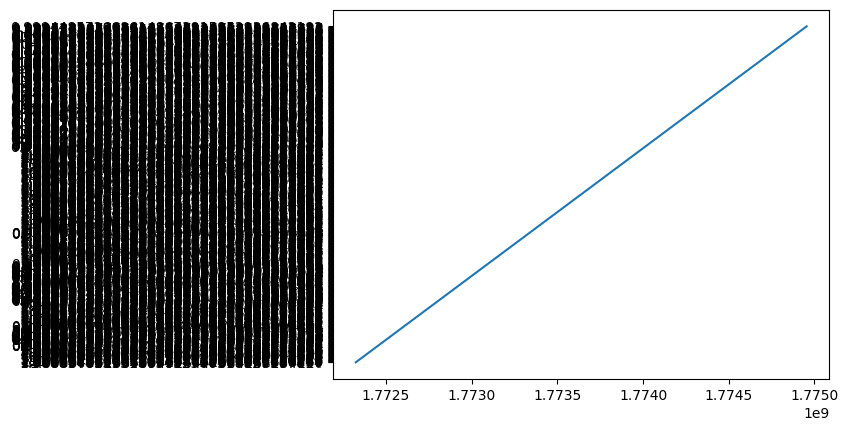

In [86]:
plt.plot(result_df["periodStartUnix"], result_df["token0Price"])

What is wrong here ? Fix the dataframe and plot again 

In [87]:
# utils.clean_df(result_df)

,close,high,id,liquidity,low,open,periodStartUnix,token0Price,token1Price,volumeUSD
0,1.000080,1.000081,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492312,46547171483978045,1.000072,1.000072,2026-03-01 00:00:00,1.000080,0.999920,2.777827e+05
1,1.000094,1.000095,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492313,46547171483978045,1.000079,1.000079,2026-03-01 01:00:00,1.000094,0.999906,4.734380e+05
2,1.000104,1.000106,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492314,40596476391285644,1.000094,1.000094,2026-03-01 02:00:00,1.000104,0.999896,3.572029e+05
3,1.000117,1.000117,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492315,40596476391285644,1.000104,1.000104,2026-03-01 03:00:00,1.000117,0.999883,4.344591e+05
4,1.000112,1.000117,0x3416cf6c708da44db2624d63ea0aaef7113527c6-492316,40596476391285644,1.000108,1.000117,2026-03-01 04:00:00,1.000112,0.999888,3.124274e+05
...,...,...,...,...,...,...,...,...,...,...
727,0.999552,0.999561,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493039,69370914678029195,0.999552,0.999560,2026-03-31 07:00:00,0.999552,1.000449,3.982446e+05
728,0.999532,0.999552,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493040,69370914678029195,0.999532,0.999552,2026-03-31 08:00:00,0.999532,1.000468,6.882702e+05
729,0.999528,0.999533,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493041,69405244432808284,0.999527,0.999531,2026-03-31 09:00:00,0.999528,1.000472,3.827389e+05
730,0.999523,0.999531,0x3416cf6c708da44db2624d63ea0aaef7113527c6-493042,69385385798818040,0.999523,0.999528,2026-03-31 10:00:00,0.999523,1.000477,4.761594e+05


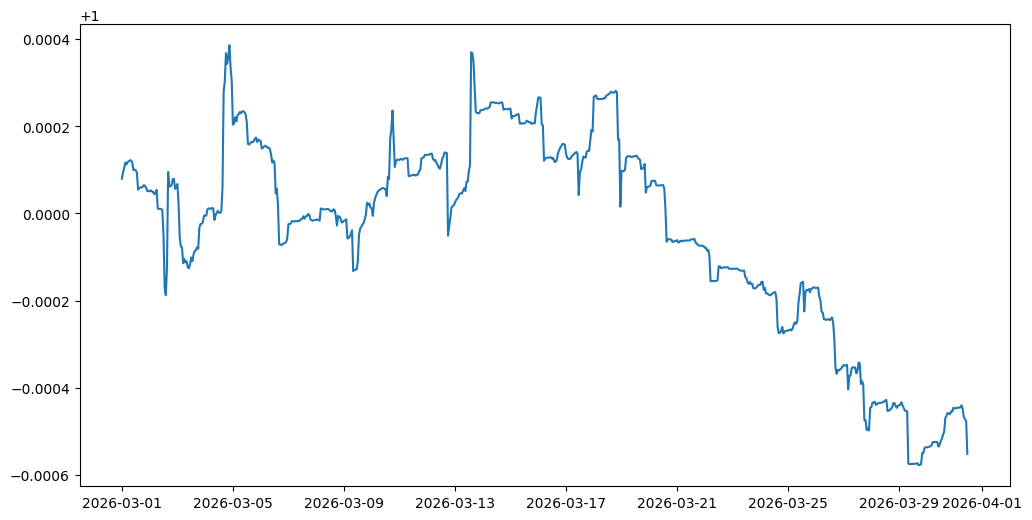

In [88]:
plt.figure(figsize=(12, 6))
plt.plot(result_df["periodStartUnix"], result_df["token0Price"])

# Another application: get the current liquidity profile

## Direct per tick liquidity from Ticks

Let us query the current liqudity curve of the USDC/USDT pool and plot it :
- first find the current active tick (center of the liqudity curve)

In [89]:
POOL_STATE_QUERY = """
query PoolState($id: ID!) {
  pool(id: $id) {
    id
    tick
    liquidity
    token0 { symbol decimals }
    token1 { symbol decimals }
  }
}
"""

pool_state = run_query(POOL_STATE_QUERY, {"id": usdc_usdt_address})["pool"]
current_tick = int(pool_state["tick"])
print("Current tick:", current_tick)

# Define bounds for the liquidity query based on the current tick
lower = str(current_tick - 40)
upper = str(current_tick + 40)


Current tick: 5


Check what the *tick* type contains: 

In [90]:
describe_type("tick")

,field,type,args
0,id,ID!,
1,poolAddress,String,
2,tickIdx,BigInt!,
3,pool,Pool!,
4,liquidityGross,BigInt!,
5,liquidityNet,BigInt!,
6,price0,BigDecimal!,
7,price1,BigDecimal!,
8,volumeToken0,BigDecimal!,
9,volumeToken1,BigDecimal!,


Query the liquidity curve : 
- Graphql allows querying around values (_gte, _le ...)
- Also allows ordering (similar to SQL)

In [91]:
LIQUIDITY_QUERY = """
query GetLiquidityCurve($id: ID!, $lower: BigInt!, $upper: BigInt!) {
  pool(id: $id) {
    id
    tick
    liquidity
    ticks(
      first: 1000
      where: {
        pool: $id
        tickIdx_gte: $lower
        tickIdx_lte: $upper
      }
      orderBy: tickIdx
      orderDirection: asc
    ) {
      id
      tickIdx
      price0
      price1
      liquidityNet
    }
}}
"""

In [92]:
raw = run_query(
    LIQUIDITY_QUERY,
    {"id": usdc_usdt_address, "lower": lower, "upper": upper}
)
ticks = pd.DataFrame(raw["pool"]["ticks"])
ticks.head()

,id,liquidityNet,price0,price1,tickIdx
0,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-35,0,0.9965062922373757462661329857381759,1.003505956550239247943832687428826,-35
1,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-34,0,0.9966059428665994838407595990367492,1.003405615988640383905442143214505,-34
2,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-33,4000897,0.9967056034608861437891436749966529,1.003305285460094374467995343680137,-33
3,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-32,0,0.9968052740212322324035225893641524,1.003204964963598014666528690811056,-32
4,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-31,5876297144,0.9969049545486343556267629416230891,1.003104654498148199846544036407415,-31


### Lets clean the data for plotting 

In [93]:
ticks["tickIdx"] = ticks["tickIdx"].astype(int)
ticks["price0"] = pd.to_numeric(ticks["price0"], errors="coerce")
ticks["price1"] = pd.to_numeric(ticks["price1"], errors="coerce")
ticks["liquidityNet"] = pd.to_numeric(ticks["liquidityNet"], errors="coerce")

token0 = pool_state["token0"]["symbol"]
token1 = pool_state["token1"]["symbol"]
dec0 = int(pool_state["token0"]["decimals"])
dec1 = int(pool_state["token1"]["decimals"])

current_liquidity = float(raw['pool']["liquidity"])

In [94]:
def build_active_liquidity_curve(ticks_df, current_tick, current_liquidity):
    ticks_df = ticks_df.sort_values("tickIdx").copy()

    below = ticks_df[ticks_df["tickIdx"] <= current_tick].sort_values("tickIdx", ascending=False).copy()
    above = ticks_df[ticks_df["tickIdx"] > current_tick].sort_values("tickIdx").copy()

    # move downward from current tick
    if not below.empty:
        below["activeLiquidity"] = current_liquidity - below["liquidityNet"].cumsum()
        below = below.sort_values("tickIdx")
    else:
        below["activeLiquidity"] = []

    # move upward from current tick
    if not above.empty:
        above["activeLiquidity"] = current_liquidity + above["liquidityNet"].cumsum()
    else:
        above["activeLiquidity"] = []

    curve = pd.concat([below, above], ignore_index=True).sort_values("tickIdx").reset_index(drop=True)
    return curve

curve = build_active_liquidity_curve(ticks, current_tick, current_liquidity)
curve.head()

,id,liquidityNet,price0,price1,tickIdx,activeLiquidity
0,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-35,0,0.996506,1.003506,-35,5.477241e+13
1,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-34,0,0.996606,1.003406,-34,5.477241e+13
2,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-33,4000897,0.996706,1.003305,-33,5.477241e+13
3,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-32,0,0.996805,1.003205,-32,5.477242e+13
4,0x3416cf6c708da44db2624d63ea0aaef7113527c6#-31,5876297144,0.996905,1.003105,-31,5.477242e+13


Text(0.5, 0, 'Price of USDC in terms of USDT')

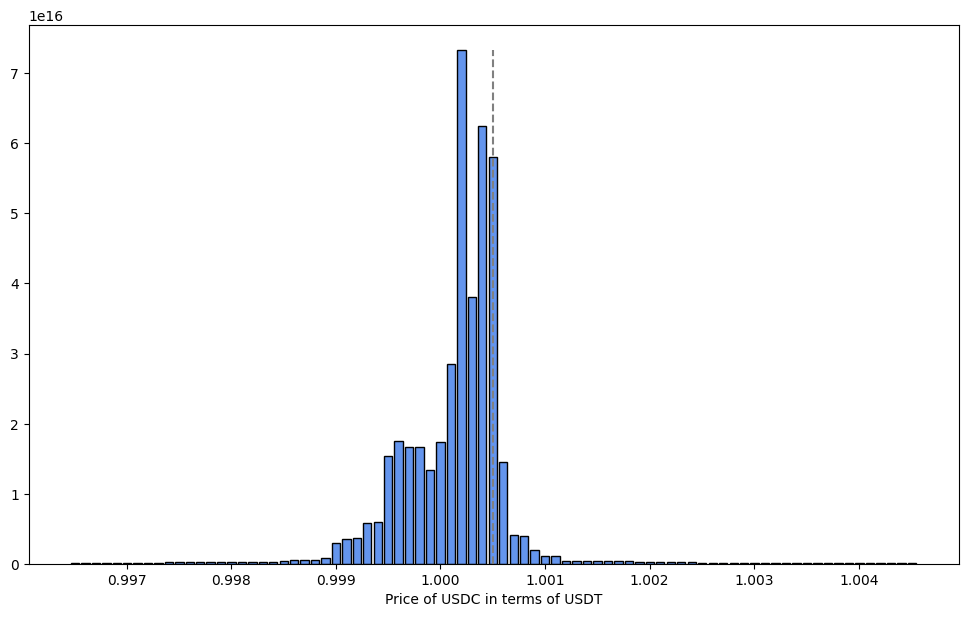

In [95]:
plt.figure(figsize=(12, 7))
plt.bar(curve["price0"], curve["activeLiquidity"], width = 0.8*(curve["price0"].diff().median()), align="center", color = "cornflowerblue", edgecolor = "black")
plt.vlines(x=(1.0001)**current_tick, ymin=0, ymax=curve["activeLiquidity"].max(), color="grey",linestyle = "--", lw=1.5)
plt.xlabel(f"Price of {token0} in terms of {token1}")

## Get open liquidity positions

In [96]:
describe_type("position")

,field,type,args
0,id,ID!,
1,owner,Bytes!,
2,pool,Pool!,
3,token0,Token!,
4,token1,Token!,
5,tickLower,Tick!,
6,tickUpper,Tick!,
7,liquidity,BigInt!,
8,depositedToken0,BigDecimal!,
9,depositedToken1,BigDecimal!,


In [97]:
LIQUIDITY_QUERY = """
query GetLiquidityCurve($id: ID!) {
  positions(first:1000, id: $id, where : {pool: $id}) {
    id
    pool{ id }
    liquidity
    owner
    tickLower { tickIdx }
    tickUpper { tickIdx }
}
}
"""

In [98]:
raw_pos = run_query(LIQUIDITY_QUERY, {"id": usdc_usdt_address})

positions = pd.DataFrame(raw_pos["positions"])
positions["tickLower"] = positions["tickLower"].apply(lambda x: int(x["tickIdx"]))
positions["tickUpper"] = positions["tickUpper"].apply(lambda x: int(x["tickIdx"]))
positions.head()

,id,liquidity,owner,pool,tickLower,tickUpper
0,1000425,0,0x18acced487c3b4432f9f9a36151d9ec0cd5a985c,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-3647,3562
1,1001700,0,0x0000000000000000000000000000000000000000,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-5,-1
2,1001766,0,0x0000000000000000000000000000000000000000,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-7,0
3,1001924,0,0x91dd5a744cfb55ccc1292922ba945e36b5ce5ddd,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-887272,887272
4,1002197,0,0x0000000000000000000000000000000000000000,{'id': '0x3416cf6c708da44db2624d63ea0aaef7113527c6'},-6,-2


We should filter the 0 liquidity positions : 

In [99]:
LIQUIDITY_QUERY = """
query GetLiquidityCurve($id: ID!) {
  positions(first:1000, id: $id, where : {pool: $id, liquidity_gt: 0}) {
    id
    pool{ id }
    liquidity
    owner
    tickLower { tickIdx }
    tickUpper { tickIdx }
}
}
"""

raw_pos = run_query(LIQUIDITY_QUERY, {"id": usdc_usdt_address})

positions = pd.DataFrame(raw_pos["positions"])
positions["tickLower"] = positions["tickLower"].apply(lambda x: int(x["tickIdx"]))
positions["tickUpper"] = positions["tickUpper"].apply(lambda x: int(x["tickIdx"]))
positions.liquidity = pd.to_numeric(positions.liquidity, errors="coerce")

Convert to a tick-by-tick liquidity :
- if a tick is inside [TickLower, TickUpper] it gets liquidity added

In [100]:
def liquidity_curve_on_ticks(
    df: pd.DataFrame,
    peg_tick: int,
    half_width: int = 50,
    tick_spacing: int = 1,
    tick_lower_col: str = "tickLower",
    tick_upper_col: str = "tickUpper",
    liquidity_col: str = "liquidity",
) -> pd.DataFrame:
    """
    Build the *active liquidity* curve L(t) over ticks in [peg_tick-half_width, peg_tick+half_width],
    where a position contributes liquidity on [tickLower, tickUpper) (inclusive of lower, exclusive of upper).

    Returns a DataFrame with columns: tick, active_liquidity

    Notes:
      - If you want an exact curve, sample at tick_spacing=1 (or ensure your sampling includes all boundary ticks).
      - liquidity is assumed additive (same units as stored in the subgraph).
    """
    if df.empty:
        return pd.DataFrame({"tick": [], "active_liquidity": []})

    start = int(peg_tick) - int(half_width)
    end   = int(peg_tick) + int(half_width)

    x = df[[tick_lower_col, tick_upper_col, liquidity_col]].copy()
    x[tick_lower_col] = pd.to_numeric(x[tick_lower_col], errors="coerce").astype("Int64")
    x[tick_upper_col] = pd.to_numeric(x[tick_upper_col], errors="coerce").astype("Int64")
    # liquidity is often a big integer encoded as string
    x[liquidity_col] = pd.to_numeric(x[liquidity_col], errors="coerce").fillna(0).astype("int64")

    # keep only positions that overlap the range at all
    x = x[(x[tick_upper_col] > start) & (x[tick_lower_col] <= end)]
    if x.empty:
        ticks = list(range(start, end + 1, tick_spacing))
        return pd.DataFrame({"tick": ticks, "active_liquidity": [0] * len(ticks)})

    # initial liquidity active at 'start'
    initial = x[(x[tick_lower_col] <= start) & (x[tick_upper_col] > start)][liquidity_col].sum()

    # deltas inside (start, end]
    add = (
        x[(x[tick_lower_col] > start) & (x[tick_lower_col] <= end)]
        .groupby(tick_lower_col)[liquidity_col]
        .sum()
    )
    sub = (
        x[(x[tick_upper_col] > start) & (x[tick_upper_col] <= end)]
        .groupby(tick_upper_col)[liquidity_col]
        .sum()
        .mul(-1)
    )
    deltas = add.add(sub, fill_value=0).to_dict()  # tick -> net change at that tick

    ticks = list(range(start, end + 1, tick_spacing))

    active = []
    L = int(initial)
    for i, t in enumerate(ticks):
        if i > 0:
            L += int(deltas.get(t, 0))
        active.append(L)

    return pd.DataFrame({"tick": ticks, "active_liquidity": active})


In [101]:
curve_from_pos = liquidity_curve_on_ticks(df = positions, peg_tick = current_tick, half_width = 40)

Text(0.5, 0, 'Price of USDC in terms of USDT')

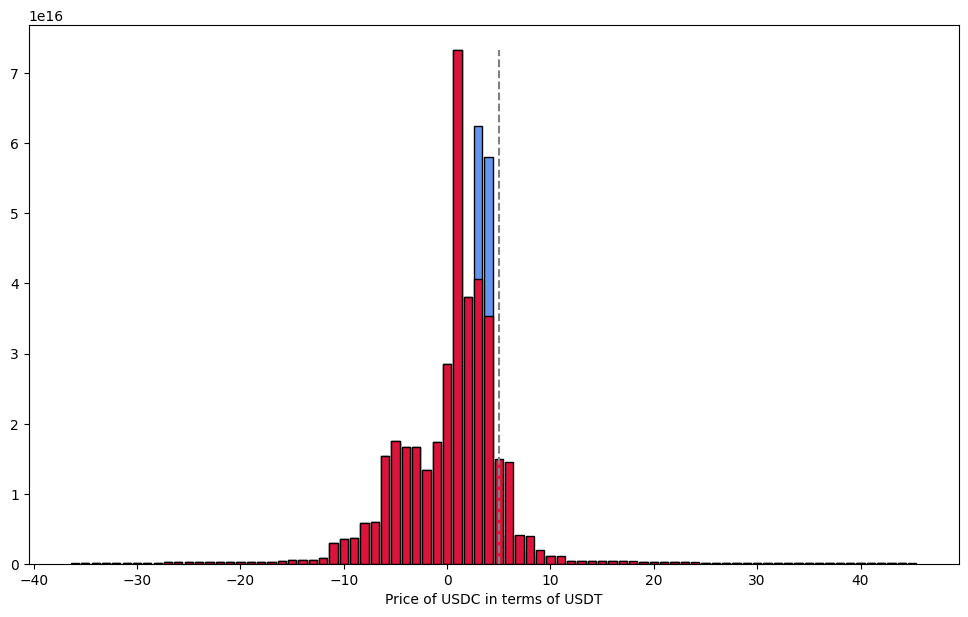

In [102]:
plt.figure(figsize=(12, 7))
plt.bar(curve["tickIdx"]-1, curve["activeLiquidity"], width = 0.8, align="center", color = "cornflowerblue", edgecolor = "black")
plt.bar(curve_from_pos["tick"], curve_from_pos["active_liquidity"], width = 0.8, align="center", color = "crimson", edgecolor = "black")
plt.vlines(x=current_tick, ymin=0, ymax=curve["activeLiquidity"].max(), color="grey",linestyle = "--", lw=1.5)
plt.xlabel(f"Price of {token0} in terms of {token1}")

- The positions are missing some liquidity
- Some liquidity is minted directly on the pool, withouth going through Uniswap's NFPM contract
    - Mostly JIT liquidity and MEV bots

> MEV liquidity is added and removed in the same block, let's query recent mints/burns to see if we can identify MEV bots.

# Collecting Mint/Burn events and Identifying MEV bots

In [103]:
# describe_type("mint")  
describe_type("burn")

,field,type,args
0,id,ID!,
1,transaction,Transaction!,
2,pool,Pool!,
3,token0,Token!,
4,token1,Token!,
5,timestamp,BigInt!,
6,owner,Bytes,
7,origin,Bytes!,
8,amount,BigInt!,
9,amount0,BigDecimal!,


Let's query the last mint events on the USDC/USDT pool :
- where pool address = USDC/USDT address
- order by decreasing timestamp

In [104]:
LIQUIDITY_QUERY = """
query GetMintsBurns($id: ID!) {
  mints(first:100, where : {pool: $id}, orderBy: timestamp, orderDirection: desc) {
    id
    owner
    origin
    sender
    amount0
    amount1
    timestamp
    tickLower { tickIdx }
    tickUpper { tickIdx }
    transaction {
      blockNumber
    }
}
}
"""

raw_mints = run_query(LIQUIDITY_QUERY, {"id": usdc_usdt_address})
mints_df = pd.DataFrame(raw_mints['mints'])
mints_df['blockNumber'] = mints_df['transaction'].apply(lambda x: x['blockNumber']).astype(int)
mints_df = mints_df.drop(columns=['transaction'])
mints_df

,amount0,amount1,id,origin,owner,sender,tickLower,tickUpper,timestamp,blockNumber
0,518823.301602,554403.312783,0x268b4b5794a0612b699b1f5032f6ff316692786fbf5d100a657a1ad5287c0d81#1748912,0x9b014d6893011ca3b049daa59b70554d8aa098f3,0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70,0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70,5,6,1774956407,24777282
1,0,503256.947434,0x73cac85f5e4bdfe2f19025975e840878db19a237a8f48634919c99154f97c11d#1748901,0xa0132fac6ab64cb1e5254d6597adbd698878ed0d,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,4,5,1774955543,24777211
2,370797.537396,1090377.023583,0x9c3b693a888d195ea9dad0aa711f7ed3709d7c6a01c1d2ee590fdcac06b269d2#1748872,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,0x1f2f10d1c40777ae1da742455c65828ff36df387,0x1f2f10d1c40777ae1da742455c65828ff36df387,4,5,1774953959,24777079
3,456440.914138,1090371.010644,0x90b527ee443582a95da9a366ec3ad18217a1d7bd48efbe55ab9884d6ed3952f6#1748867,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,0x1f2f10d1c40777ae1da742455c65828ff36df387,0x1f2f10d1c40777ae1da742455c65828ff36df387,4,5,1774953767,24777063
4,3956.289548,4625.337279,0x3512093a208d377a6c387a304ed90dbff0b4b57af9aeeb6bbe06cec34241d0e3#1748800,0xf18dfa63ba2b4885cecfcfec6d164747d6db7aca,0xc36442b4a4522e871399cd717abdd847ab11fe88,0xc36442b4a4522e871399cd717abdd847ab11fe88,2,7,1774948331,24776614
...,...,...,...,...,...,...,...,...,...,...
95,350435.540427,1082911.521403,0x3178682e103eea03c0b309f2f6206a9d40c40fb48eb8e88dd6db235aa33ecd59#1745107,0xae2fc483527b8ef99eb5d9b44875f005ba1fae13,0x1f2f10d1c40777ae1da742455c65828ff36df387,0x1f2f10d1c40777ae1da742455c65828ff36df387,3,4,1774588091,24746706
96,262374.440616,810810.057228,0xed7421f1235fb0cffeb42b8ae4de7c8db1f5f891b80d91b47d1073787c5142ba#1745104,0x9b014d6893011ca3b049daa59b70554d8aa098f3,0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70,0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70,3,4,1774587875,24746688
97,318549.243665,754454.380888,0x633131b28f7c869055b3e75841194912b4cb26e398376babd139506e964619f4#1745079,0x9b014d6893011ca3b049daa59b70554d8aa098f3,0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70,0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70,4,5,1774586423,24746570
98,12400.365038,3248270.248127,0xefdfa544351a17480e4219946422745152a686e122aa3250415b6b542055c65d#1745064,0x9b014d6893011ca3b049daa59b70554d8aa098f3,0x28ac01d4790ed04b378ca32c90e443b3cb6358cd,0x28ac01d4790ed04b378ca32c90e443b3cb6358cd,3,5,1774585499,24746493


- Since the events tracked are mints owner == sender
- Owner is the smart contract calling mint on the pool
- Origin is the wallet (EOA) owning the liquidity

In [105]:
mints_df.owner.value_counts().head(10)

owner
0x1f2f10d1c40777ae1da742455c65828ff36df387    48
0xc36442b4a4522e871399cd717abdd847ab11fe88    41
0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70     7
0x8c209c15835cccb2984701b52651d2c8d83aa442     2
0x28ac01d4790ed04b378ca32c90e443b3cb6358cd     2
Name: count, dtype: int64

> A visit to etherscan shows that 0xc36442b4a4522e871399cd717abdd847ab11fe88 is the address of the uniswap positions manager
https://etherscan.io/address/0xc36442b4a4522e871399cd717abdd847ab11fe88

- Let's update our query ! (let's also query burns)

In [106]:
nfpm = "0xc36442b4a4522e871399cd717abdd847ab11fe88".lower()
LIQUIDITY_QUERY = """
query GetMintsBurns($id: ID!, $nfpm: String!) {
  mints(first:100, where : {pool: $id, owner_not: $nfpm}, orderBy: timestamp, orderDirection: desc) {
    id
    owner
    origin
    amount
    amount0
    amount1
    tickLower { tickIdx }
    tickUpper { tickIdx }
    transaction {
      blockNumber
    }
}
  burns(first:100, where : {pool: $id, owner_not: $nfpm}, orderBy: timestamp, orderDirection: desc) {
    id
    owner
    origin
    amount
    amount0
    amount1
    tickLower { tickIdx }
    tickUpper { tickIdx }
    transaction {
      blockNumber
    }
}
}
"""

raw_mints_burns = run_query(LIQUIDITY_QUERY, {"id": usdc_usdt_address, "nfpm": nfpm})
mints_df = pd.DataFrame(raw_mints_burns['mints'])
mints_df['blockNumber'] = mints_df['transaction'].apply(lambda x: x['blockNumber']).astype(int)
mints_df = mints_df.drop(columns=['transaction'])
burns_df = pd.DataFrame(raw_mints_burns['burns'])
burns_df['blockNumber'] = burns_df['transaction'].apply(lambda x: x['blockNumber']).astype(int)
burns_df = burns_df.drop(columns=['transaction'])

In [107]:
mints_df.owner.value_counts().head(10)

owner
0x1f2f10d1c40777ae1da742455c65828ff36df387    79
0x81ae6a1ff1fc329a052689a7a0a5b0372b6beb70    13
0x8c209c15835cccb2984701b52651d2c8d83aa442     4
0x28ac01d4790ed04b378ca32c90e443b3cb6358cd     4
Name: count, dtype: int64

Now etherscan shows that the most active SC is a known MEV bot : https://etherscan.io/address/0x1f2f10d1c40777ae1da742455c65828ff36df387

- let's check its behavior, looking at the last mint:

In [108]:
last_mint = mints_df.query('owner == "0x1f2f10d1c40777ae1da742455c65828ff36df387"').iloc[-1]
last_mint

amount                                                                  24905481403236352
amount0                                                                     152142.191424
amount1                                                                    1093133.508751
id             0xe3526d62a25637af3e6cb5c60b0707a449f4fb72ee72bcb6f050a7feee2e30e0#1741436
origin                                         0xae2fc483527b8ef99eb5d9b44875f005ba1fae13
owner                                          0x1f2f10d1c40777ae1da742455c65828ff36df387
tickLower                                                                               1
tickUpper                                                                               2
blockNumber                                                                      24726320
Name: 99, dtype: object

There is a corresponding burn of the same amount of liquidity on the same block:

In [109]:
last_burn = burns_df.query('owner == "0x1f2f10d1c40777ae1da742455c65828ff36df387"').iloc[-1]
last_burn

amount                                                                  24905481403236352
amount0                                                                     154952.544432
amount1                                                                    1090322.628305
id             0xf179db464d7b5c23b7b4fa261f7e583bc46b534b35d6a72f22803495c8ee3433#1741438
origin                                         0xae2fc483527b8ef99eb5d9b44875f005ba1fae13
owner                                          0x1f2f10d1c40777ae1da742455c65828ff36df387
tickLower                                                                               1
tickUpper                                                                               2
blockNumber                                                                      24726320
Name: 99, dtype: object

> Compute what percentage of active liquidity at Tick one this MEV bot had 

- query the liquidity curve (specify the correct blockNumber)
- Verify that this position overlaps the price at that time
- Find proportion of active liquidity

# Polymarket Data Collection

- Polymarket indexes several subgraphs for different aspects of the platform; subgraphs are publicly hosted on goldsky
- Polymarket also hosts an API for trading/data collection on the centralized parts of the platform. https://docs.polymarket.com/api-reference/introduction
- Data collection needs to be done with subgraphs and the gamma API in conjunction


> Since the data is more complex on Polymarket, we give some basic ideas on collection and leave more complex analysis for later 

In [110]:
# Set up environment
GAMMA_API = "https://gamma-api.polymarket.com"
CLOB_API = "https://clob.polymarket.com"
GOLDSKY_PNL = "https://api.goldsky.com/api/public/project_cl6mb8i9h0003e201j6li0diw/subgraphs/pnl-subgraph/0.0.14/gn"
GOLDSKY_OI = "https://api.goldsky.com/api/public/project_cl6mb8i9h0003e201j6li0diw/subgraphs/oi-subgraph/0.0.6/gn"
GOLDSKY_ORDER = "https://api.goldsky.com/api/public/project_cl6mb8i9h0003e201j6li0diw/subgraphs/orderbook-subgraph/0.0.1/gn"
session = requests.Session()

- let's view the fields on the Polymarket subgraph:

#### Pnl subgraph

In [134]:
schema = run_query(INTROSPECTION_QUERY, url=GOLDSKY_PNL)["__schema"]
print("Query type:", schema["queryType"]["name"])
print("Number of schema types:", len(schema["types"]))
types_by_name = {t["name"]: t for t in schema["types"]}
query_type = types_by_name[schema["queryType"]["name"]]
query_rows = []
for field in query_type["fields"]:
    arg_names = [a["name"] for a in field.get("args", [])]
    query_rows.append({
        "field": field["name"],
        "returns": pretty_type(field["type"]),
        "base_type": base_type_name(field["type"]),
        "args": ", ".join(arg_names),
        "has_where": "where" in arg_names,
        "has_block": "block" in arg_names,
        "has_orderBy": "orderBy" in arg_names,
        "has_first": "first" in arg_names,
        "has_skip": "skip" in arg_names,
    })

query_fields_df = pd.DataFrame(query_rows).sort_values(
    ["has_where", "has_block", "field"],
    ascending=[False, False, True]
)

query_fields_df.head(50)

Query type: Query
Number of schema types: 30


,field,returns,base_type,args,has_where,has_block,has_orderBy,has_first,has_skip
5,conditions,[Condition!]!,Condition,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
7,fpmms,[FPMM!]!,FPMM,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
3,negRiskEvents,[NegRiskEvent!]!,NegRiskEvent,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
1,userPositions,[UserPosition!]!,UserPosition,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
8,_meta,_Meta_,_Meta_,block,False,True,False,False,False
4,condition,Condition,Condition,"id, block, subgraphError",False,True,False,False,False
6,fpmm,FPMM,FPMM,"id, block, subgraphError",False,True,False,False,False
2,negRiskEvent,NegRiskEvent,NegRiskEvent,"id, block, subgraphError",False,True,False,False,False
0,userPosition,UserPosition,UserPosition,"id, block, subgraphError",False,True,False,False,False


In [135]:
describe_type("condition")

,field,type,args
0,id,ID!,
1,positionIds,[BigInt!]!,
2,payoutNumerators,[BigInt!]!,
3,payoutDenominator,BigInt!,


#### Open Interest

In [136]:
schema = run_query(INTROSPECTION_QUERY, url=GOLDSKY_OI)["__schema"]
print("Query type:", schema["queryType"]["name"])
print("Number of schema types:", len(schema["types"]))
types_by_name = {t["name"]: t for t in schema["types"]}
query_type = types_by_name[schema["queryType"]["name"]]
query_rows = []
for field in query_type["fields"]:
    arg_names = [a["name"] for a in field.get("args", [])]
    query_rows.append({
        "field": field["name"],
        "returns": pretty_type(field["type"]),
        "base_type": base_type_name(field["type"]),
        "args": ", ".join(arg_names),
        "has_where": "where" in arg_names,
        "has_block": "block" in arg_names,
        "has_orderBy": "orderBy" in arg_names,
        "has_first": "first" in arg_names,
        "has_skip": "skip" in arg_names,
    })

query_fields_df = pd.DataFrame(query_rows).sort_values(
    ["has_where", "has_block", "field"],
    ascending=[False, False, True]
)

query_fields_df.head(50)

Query type: Query
Number of schema types: 30


,field,returns,base_type,args,has_where,has_block,has_orderBy,has_first,has_skip
1,conditions,[Condition!]!,Condition,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
7,globalOpenInterests,[GlobalOpenInterest!]!,GlobalOpenInterest,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
5,marketOpenInterests,[MarketOpenInterest!]!,MarketOpenInterest,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
3,negRiskEvents,[NegRiskEvent!]!,NegRiskEvent,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
8,_meta,_Meta_,_Meta_,block,False,True,False,False,False
0,condition,Condition,Condition,"id, block, subgraphError",False,True,False,False,False
6,globalOpenInterest,GlobalOpenInterest,GlobalOpenInterest,"id, block, subgraphError",False,True,False,False,False
4,marketOpenInterest,MarketOpenInterest,MarketOpenInterest,"id, block, subgraphError",False,True,False,False,False
2,negRiskEvent,NegRiskEvent,NegRiskEvent,"id, block, subgraphError",False,True,False,False,False


In [137]:
describe_type("marketOpenInterest")

,field,type,args
0,id,ID!,
1,amount,BigInt!,


#### Orders

In [138]:
schema = run_query(INTROSPECTION_QUERY, url=GOLDSKY_ORDER)["__schema"]
print("Query type:", schema["queryType"]["name"])
print("Number of schema types:", len(schema["types"]))
types_by_name = {t["name"]: t for t in schema["types"]}
query_type = types_by_name[schema["queryType"]["name"]]
query_rows = []
for field in query_type["fields"]:
    arg_names = [a["name"] for a in field.get("args", [])]
    query_rows.append({
        "field": field["name"],
        "returns": pretty_type(field["type"]),
        "base_type": base_type_name(field["type"]),
        "args": ", ".join(arg_names),
        "has_where": "where" in arg_names,
        "has_block": "block" in arg_names,
        "has_orderBy": "orderBy" in arg_names,
        "has_first": "first" in arg_names,
        "has_skip": "skip" in arg_names,
    })

query_fields_df = pd.DataFrame(query_rows).sort_values(
    ["has_where", "has_block", "field"],
    ascending=[False, False, True]
)

query_fields_df.head(50)

Query type: Query
Number of schema types: 33


,field,returns,base_type,args,has_where,has_block,has_orderBy,has_first,has_skip
1,marketDatas,[MarketData!]!,MarketData,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
3,orderFilledEvents,[OrderFilledEvent!]!,OrderFilledEvent,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
7,orderbooks,[Orderbook!]!,Orderbook,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
5,ordersMatchedEvents,[OrdersMatchedEvent!]!,OrdersMatchedEvent,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
9,ordersMatchedGlobals,[OrdersMatchedGlobal!]!,OrdersMatchedGlobal,"skip, first, orderBy, orderDirection, where, block, subgraphError",True,True,True,True,True
10,_meta,_Meta_,_Meta_,block,False,True,False,False,False
0,marketData,MarketData,MarketData,"id, block, subgraphError",False,True,False,False,False
2,orderFilledEvent,OrderFilledEvent,OrderFilledEvent,"id, block, subgraphError",False,True,False,False,False
6,orderbook,Orderbook,Orderbook,"id, block, subgraphError",False,True,False,False,False
4,ordersMatchedEvent,OrdersMatchedEvent,OrdersMatchedEvent,"id, block, subgraphError",False,True,False,False,False


In [139]:
describe_type("marketData")

,field,type,args
0,id,ID!,
1,condition,String!,
2,outcomeIndex,BigInt,


### Basic queries

In [141]:
POS_QUERY = """
query getUserPositions($first: Int!) {
  userPositions(first: $first) {
    id
    user 
    tokenId
    amount
    avgPrice
    realizedPnl
    totalBought
}
}
"""

raw = run_query(POS_QUERY, {"first": 100}, url=GOLDSKY_PNL)
pos_df= pd.DataFrame(raw['userPositions'])

In [142]:
POS_QUERY = """
query getUserPositions($first: Int!) {
  conditions(first: $first) {
    id
    positionIds
    payoutNumerators
}
}
"""

raw = run_query(POS_QUERY, {"first": 100}, url=GOLDSKY_PNL)
pos_df= pd.DataFrame(raw['userPositions'])

KeyError: 'userPositions'

In [ ]:
pos_df

In [119]:
OI_QUERY = """
query getUserPositions($first: Int!) {
  marketOpenInterests(first: $first) {
    id
    amount
}
}
"""

raw = run_query(OI_QUERY, {"first": 10}, url=GOLDSKY_OI)
oi_df= pd.DataFrame(raw['marketOpenInterests'])
oi_df

,id,amount
0,0x00000977017fa72fb6b1908ae694000d3b51f442c2552656b10bdbbfd16ff707,826703560
1,0x00005c113846891686d99ff1d145ded8bdccfa028df0fdf15d66f11d176c49b1,0
2,0x00008da19716178aee4234373ea8702fabd5088d030e7d2b3b38a3637fb69167,22991178
3,0x0000a3aa2ac9a909841538e97750d8cf5ef95fdf46b74a3d670e50771c58bbed,0
4,0x0000bd14c46a76b3cf2d7bdb48e39f21ecef57130b0ad8681e51d938e5715296,18846
5,0x0000dbb9f89318fa1324d4eed3dbc1ff192e764138c7f9e9be6e9079e1fb3d4f,23154
6,0x0000e7c9418bd82e7c7b1236952030abcefcdfff6e13fabc87eda3147fae6936,15931200
7,0x000115170c7db87d5af2ab8eb3112d39699722fd936b682714d6fd9a4f595a5c,0
8,0x000122ff0329632a7e264073891260ee3dbcd013f3f57bd9a39f81633d3c7587,2000
9,0x000149d7a2971f4ba69343b6ebc8b5d76a29b2f20caa7b7041ae2f2da0a448f3,4923


In [122]:
OI_QUERY = """
query getUserPositions($first: Int!) {
  marketDatas(first: $first) {
    id
    condition
}
}
"""

raw = run_query(OI_QUERY, {"first": 10}, url=GOLDSKY_ORDER)
oi_df= pd.DataFrame(raw['marketDatas'])
oi_df

,id,condition
0,100000194858224654405562354491635866583781698915837339043395252497294858676738,0xb09a659b55f0eab385d75ef14d180e9a6b2f02290a427504e38bf803e35d25d6
1,100000199165919327734058373397899695829815497509562888400509981134055164952234,0x4864d05263216b7e16ceea73def05de623a35cc2bc488363834ae6989cbc7f0b
2,100000293804690815023609597660894660801582658691499546225810764430851148723524,0x2c0b5356580361d997ce3d29d38d5eceeb7a90650186f9c0f6f2844bebf1ff71
3,10000031503135974591606954648111634303732450856683949269069499510289764175701,0xac5c279f4aa0fe1cadcbec6ce9d49e470af55e9fa87643de6f5ce8f887e0a5b9
4,100000344086769652449958474633411048953080395223832069537559409381328488772595,0x82bf17e43f9eb42d29580f93e58d265aac3af1d3e8e198b82b2ad6be0801ab63
5,10000035396867127198183452241369158062657991925922993808094682810784450190958,0xb5e3cdf5f63600ecaab8933f8baf9873d4ab36028a378964dea77563a7bb1948
6,100000387803377432102632436647408425727122036893140724256808391635446206358353,0x7a3beb3a8a2c2fc7b09974f2fce1351ca64e2716983e3141d518b4f561b11e2e
7,100000406379544077785650145286165989481026405241009239362293418645989760421039,0x0eb12e9cf39c1c8dd47664bd0693ee537d2297f7e5f4530d0952a7cf1203a3f7
8,100000421701398085254381582196984649646075582786226254803672650757933913960059,0x9a7cb32ee815f43d4b07b7f18bad46e4ca1779d2081f1ede8d3dd79a037bb4b4
9,100000490830271269851920749661415771692780615224041386325838995197097673897250,0xd7ee0528c04c33761ec545da538ffeabcae04602bc19c9e035cdafb697dae325


In [123]:
def get_market(slug=None, market_id=None, active=True, closed=False, limit=1):
    if market_id is not None:
        r = requests.get(f"{GAMMA_API}/markets/{market_id}", timeout=30)
        r.raise_for_status()
        return r.json()

    params = {"limit": limit}
    if slug is not None:
        params["slug"] = slug
    else:
        params["active"] = str(active).lower()
        params["closed"] = str(closed).lower()

    r = requests.get(f"{GAMMA_API}/markets", params=params, timeout=30)
    r.raise_for_status()
    markets = r.json()

    if len(markets) == 0:
        raise ValueError("No market found with these parameters.")

    return markets[0]

In [124]:
market = get_market(slug="will-apple-release-a-new-product-line-before-2027")  # replace with any slug you want

question = market["question"]
condition_id = market["conditionId"]
market_id = market["id"]

# Per docs, clobTokenIds is [Yes token ID, No token ID]
yes_token, no_token = market["clobTokenIds"].split('"')[1::2]
print("Question:", question)
print("Market ID:", market_id)
print("Condition ID:", condition_id)
print("Yes token:", yes_token)
print("No token:", no_token)

Question: Will Apple release a new product line before 2027?
Market ID: 920210
Condition ID: 0x0a84cdeb03a25ae441697191edbcc31ad6803c3f4d48af2e0429952336c04fc1
Yes token: 32842597925388411947401997144667159337666668967988464279723455370811463728753
No token: 99286648655633868231744185944605567361660243879695992570555682921500736029261


In [ ]:
def fetch_condition_positions(condition_id):
    query = """
    query Cond($id: ID!) {
      condition(id: $id) {
        id
        positionIds
      }
    }
    """
    data = gql(GOLDSKY_PNL, query, {"id": condition_id})
    return data.get("condition")


def fetch_order_marketdata(condition_id):
    query = """
    query MD($condition: String!) {
      marketDatas(where: { condition: $condition }) {
        id
        outcomeIndex
        condition
      }
    }
    """
    data = gql(GOLDSKY_ORDER, query, {"condition": condition_id})
    return data["marketDatas"]


def fetch_gamma_market(condition_id):
    r = requests.get(
        GAMMA_MARKETS,
        params={"condition_ids": condition_id},
        timeout=30,
    )
    r.raise_for_status()
    markets = r.json()
    if not markets:
        return None
    return markets[0]


def parse_clob_token_ids(value):
    if value is None:
        return None
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        try:
            return json.loads(value)
        except Exception:
            return value
    return value


def enrich_top_oi(n=20, page_size=500, max_pages=None, min_amount=1):
    rows = []
    top = fetch_top_oi(
        n=n
    )

    for m in top:
        condition_id = m["id"]
        oi_amount = int(m["amount"])

        # token ids from PNL
        pnl_cond = fetch_condition_positions(condition_id)
        pnl_token_ids = pnl_cond["positionIds"] if pnl_cond else []

        # token ids from orderbook
        order_tokens = fetch_order_marketdata(condition_id)
        order_token_ids = [x["id"] for x in order_tokens]

        # metadata from Gamma
        gamma = fetch_gamma_market(condition_id)

        row = {
            "condition_id": condition_id,
            "oi_amount": oi_amount,
            "token_ids_pnl": pnl_token_ids,
            "token_ids_order": order_token_ids,
            "question_id": gamma.get("questionID") if gamma else None,
            "question": gamma.get("question") if gamma else None,
            "slug": gamma.get("slug") if gamma else None,
            "clob_token_ids": parse_clob_token_ids(gamma.get("clobTokenIds")) if gamma else None,
        }
        rows.append(row)

    return rows


# example
rows = enrich_top_oi(
    n=10,
    page_size=500,   # can reduce to 200 if needed
    max_pages=20,    # optional safety cap; remove if you want all pages
    min_amount=1,
)

for r in rows:
    print("=" * 80)
    print(f"condition_id   : {r['condition_id']}")
    print(f"oi_amount      : {r['oi_amount']}")
    print(f"question_id    : {r['question_id']}")
    print(f"slug           : {r['slug']}")
    print(f"question       : {r['question']}")
    print(f"token_ids_pnl  : {r['token_ids_pnl']}")
    print(f"token_ids_order: {r['token_ids_order']}")
    print(f"clob_token_ids : {r['clob_token_ids']}")

RuntimeError: [{'message': 'Failed to get entities from store: canceling statement due to statement timeout, query = /* controller=\'filter\',application=\'sgd2915\',route=\'e6128a6137e30ca5-6dc8c4ef99f8cc6a\',action=\'84919525\' */\nselect \'MarketOpenInterest\' as entity, to_jsonb(c.*) as data from (select c."amount", c."block_range", c."id", c."vid"\n  from "sgd2915"."market_open_interest" as c\n where c.block_range @> $1 and coalesce(upper(c.block_range), 2147483647) > $2 and lower(c.block_range) <= $3 and (c."amount" > $4::numeric and c."id" > $5)\n\n order by "id", block_range\n limit 500) c -- binds: [84919525, 84919525, 84919525, "0", ""]'}]